## 1. Import knižníc

In [2]:

import sys
from pathlib import Path

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))

from models.feature_extraction import FeatureExtractor
from models.utils import get_device
from utils.clustering import (
    reduce_dimensionality,
    cluster_features,
    visualize_clusters_2d,
    display_cluster_samples,
    compute_average_images,
    analyze_clusters,
)
from utils.evaluation import (
    plot_training_history,
    plot_residuals,
    plot_predictions_comparison,
)

print(f"Verzia PyTorch: {torch.__version__}")

try:
    import intel_extension_for_pytorch as ipex
    print(f"Intel Extension for PyTorch: {ipex.__version__}")
except (ImportError, OSError) as e:
    print(f"Intel Extension for PyTorch nie je dostupné: {e}")

if hasattr(torch, 'xpu') and torch.xpu.is_available():
    print(f"Intel XPU dostupné: {torch.xpu.device_count()} zariadení")
    for i in range(torch.xpu.device_count()):
        print(f"  [{i}]: {torch.xpu.get_device_name(i)}")
else:
    print("Používa sa CPU (GPU nebolo detekované)")

device = get_device()

Verzia PyTorch: 2.7.0+xpu
Intel Extension for PyTorch: 2.7.10+xpu
Intel XPU dostupné: 1 zariadení
  [0]: Intel(R) Arc(TM) B580 Graphics
Intel Arc GPU detected: Intel(R) Arc(TM) B580 Graphics
Intel XPU dostupné: 1 zariadení
  [0]: Intel(R) Arc(TM) B580 Graphics
Intel Arc GPU detected: Intel(R) Arc(TM) B580 Graphics


## 2. Načítanie spracovaných dát

In [20]:
data_dir = project_root / "dataset" / "Solar_data"
processed_dir = project_root / "dataset" / "processed"

train_df = pl.read_csv(processed_dir / "train.csv")
val_df = pl.read_csv(processed_dir / "val.csv")
test_df = pl.read_csv(processed_dir / "test.csv")

print(f"Trénovacie vzorky: {len(train_df)}")
print(f"Validačné vzorky: {len(val_df)}")
print(f"Testovacie vzorky: {len(test_df)}")

# Zobrazenie štatistík cieľovej premennej
print(f"\nŠtatistiky Irradiance:")
print(f"  Trénovacie - priemer: {train_df['Irradiance'].mean():.2f}, std: {train_df['Irradiance'].std():.2f}")
print(f"  Validačné  - priemer: {val_df['Irradiance'].mean():.2f}, std: {val_df['Irradiance'].std():.2f}")
print(f"  Testovacie - priemer: {test_df['Irradiance'].mean():.2f}, std: {test_df['Irradiance'].std():.2f}")

Trénovacie vzorky: 4204
Validačné vzorky: 901
Testovacie vzorky: 902

Štatistiky Irradiance:
  Trénovacie - priemer: 297.71, std: 281.30
  Validačné  - priemer: 299.44, std: 286.58
  Testovacie - priemer: 304.90, std: 284.23


## 3. Výber predtrénovaného modelu pre extrakciu príznakov

Vyberieme MobileNetV2 (menší počet parametrov = rýchlejšie výpočty)

In [4]:
model_name = "mobilenet_v2"  # Môžeme vyskúšať aj 'resnet18' alebo 'efficientnet_b0'

print(f"Vybraný model: {model_name}")
print("\nInicializácia Feature Extractor...")

feature_extractor = FeatureExtractor(model_name=model_name, device=device)

print(f"Model úspešne načítaný na zariadenie: {device}")
print(f"Veľkosť výstupného feature vektora: {feature_extractor.feature_dim}")

Vybraný model: mobilenet_v2

Inicializácia Feature Extractor...
Model úspešne načítaný na zariadenie: xpu
Veľkosť výstupného feature vektora: 1280
Model úspešne načítaný na zariadenie: xpu
Veľkosť výstupného feature vektora: 1280


## 4. Extrakcia príznakov z obrázkov

Použijeme predtrénovaný model na extrakciu príznakov zo všetkých obrázkov.

In [5]:
print("="*80)
print("EXTRAKCIA PRÍZNAKOV Z TRÉNOVACEJ MNOŽINY")
print("="*80)
train_features_df = feature_extractor.extract_features_from_dataframe(
    train_df, 
    data_dir,
    batch_size=64,
    use_resized=True
)

print("\n" + "="*80)
print("EXTRAKCIA PRÍZNAKOV Z VALIDAČNEJ MNOŽINY")
print("="*80)
val_features_df = feature_extractor.extract_features_from_dataframe(
    val_df,
    data_dir,
    batch_size=64,
    use_resized=True
)

print("\n" + "="*80)
print("EXTRAKCIA PRÍZNAKOV Z TESTOVACEJ MNOŽINY")
print("="*80)
test_features_df = feature_extractor.extract_features_from_dataframe(
    test_df,
    data_dir,
    batch_size=64,
    use_resized=True
)

print("\n" + "="*80)
print("EXTRAKCIA PRÍZNAKOV DOKONČENÁ")
print("="*80)
print(f"Trénovacie príznaky: {train_features_df.shape}")
print(f"Validačné príznaky: {val_features_df.shape}")
print(f"Testovacie príznaky: {test_features_df.shape}")

EXTRAKCIA PRÍZNAKOV Z TRÉNOVACEJ MNOŽINY


Extrakcia príznakov (mobilenet_v2): 100%|██████████| 66/66 [00:31<00:00,  2.08it/s]




 Extrakcia dokončená: 4204 vzoriek, 62720 príznakov

EXTRAKCIA PRÍZNAKOV Z VALIDAČNEJ MNOŽINY


Extrakcia príznakov (mobilenet_v2): 100%|██████████| 15/15 [00:06<00:00,  2.44it/s]




 Extrakcia dokončená: 901 vzoriek, 62720 príznakov

EXTRAKCIA PRÍZNAKOV Z TESTOVACEJ MNOŽINY


Extrakcia príznakov (mobilenet_v2): 100%|██████████| 15/15 [00:06<00:00,  2.46it/s]




 Extrakcia dokončená: 902 vzoriek, 62720 príznakov

EXTRAKCIA PRÍZNAKOV DOKONČENÁ
Trénovacie príznaky: (4204, 62722)
Validačné príznaky: (901, 62722)
Testovacie príznaky: (902, 62722)


## 5. Uloženie extrahovaných príznakov do DataFrame

In [6]:
features_dir = processed_dir / "features"
features_dir.mkdir(exist_ok=True)

train_features_df.write_csv(features_dir / f"train_features_{model_name}.csv")
val_features_df.write_csv(features_dir / f"val_features_{model_name}.csv")
test_features_df.write_csv(features_dir / f"test_features_{model_name}.csv")

print(f"Príznaky uložené do: {features_dir}")
print(f"  - train_features_{model_name}.csv")
print(f"  - val_features_{model_name}.csv")
print(f"  - test_features_{model_name}.csv")

print(f"\nPríklad štruktúry DataFrame:")
print(train_features_df.head(3))

Príznaky uložené do: c:\Users\pmuzslay\suns_z3\dataset\processed\features
  - train_features_mobilenet_v2.csv
  - val_features_mobilenet_v2.csv
  - test_features_mobilenet_v2.csv

Príklad štruktúry DataFrame:
shape: (3, 62_722)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ feature_0 ┆ feature_1 ┆ feature_2 ┆ feature_3 ┆ … ┆ feature_6 ┆ feature_6 ┆ image_pat ┆ Irradian │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ 2718      ┆ 2719      ┆ h         ┆ ce       │
│ f32       ┆ f32       ┆ f32       ┆ f32       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆ f32       ┆ f32       ┆ str       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 0.117073  ┆ 0.0       ┆ 0.0       ┆ 0.102833  ┆ … ┆ 0.0       ┆ 0.0       ┆ c:\Users\ ┆ 278.25   │
│           ┆           ┆           ┆           ┆   ┆           ┆

## 6. Redukcia dimenzie príznakov (PCA)

Pre vizualizáciu a zhlukovanie znížime dimenziu príznakov pomocou PCA.

Pôvodná dimenzia príznakov: 62720
PCA: 50 komponentov vysvetľuje 74.81% variancie
Redukovaná dimenzia: 50
Vysvetlený rozptyl (prvých 10 komponentov): [0.16450778 0.11752673 0.06423116 0.04778347 0.03608416 0.02878849
 0.02443118 0.02247932 0.01719182 0.0159415 ]
Celkový vysvetlený rozptyl: 0.7481
PCA: 50 komponentov vysvetľuje 74.81% variancie
Redukovaná dimenzia: 50
Vysvetlený rozptyl (prvých 10 komponentov): [0.16450778 0.11752673 0.06423116 0.04778347 0.03608416 0.02878849
 0.02443118 0.02247932 0.01719182 0.0159415 ]
Celkový vysvetlený rozptyl: 0.7481


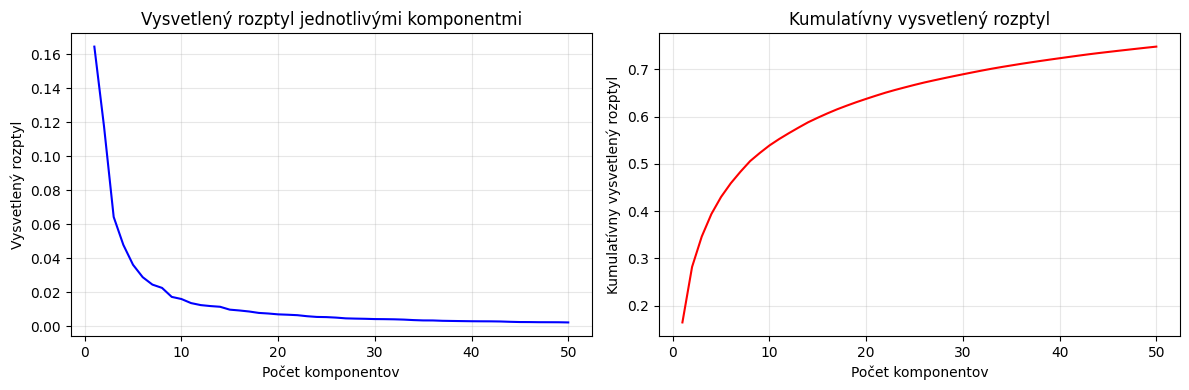

In [7]:
# Vyber iba feature stĺpce (bez ImagePath a Irradiance)
feature_cols = [col for col in train_features_df.columns if col.startswith('feature_')]

# Konverzia na numpy array pre PCA
X_train = train_features_df.select(feature_cols).to_numpy()
X_val = val_features_df.select(feature_cols).to_numpy()
X_test = test_features_df.select(feature_cols).to_numpy()

print(f"Pôvodná dimenzia príznakov: {X_train.shape[1]}")

# Redukcia dimenzie na 50 komponentov pre zhlukovanie
n_components = 50
X_train_reduced, pca_model = reduce_dimensionality(
    X_train, 
    method='pca', 
    n_components=n_components
)
X_val_reduced = pca_model.transform(X_val)
X_test_reduced = pca_model.transform(X_test)

print(f"Redukovaná dimenzia: {X_train_reduced.shape[1]}")
print(f"Vysvetlený rozptyl (prvých 10 komponentov): {pca_model.explained_variance_ratio_[:10]}")
print(f"Celkový vysvetlený rozptyl: {pca_model.explained_variance_ratio_.sum():.4f}")

# Vizualizácia vysvetleného rozptylu
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(pca_model.explained_variance_ratio_) + 1), 
         pca_model.explained_variance_ratio_, 'b-')
plt.xlabel('Počet komponentov')
plt.ylabel('Vysvetlený rozptyl')
plt.title('Vysvetlený rozptyl jednotlivými komponentmi')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(pca_model.explained_variance_ratio_) + 1), 
         np.cumsum(pca_model.explained_variance_ratio_), 'r-')
plt.xlabel('Počet komponentov')
plt.ylabel('Kumulatívny vysvetlený rozptyl')
plt.title('Kumulatívny vysvetlený rozptyl')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Zhlukovanie príznakov pomocou K-Means

Použijeme K-Means na vytvorenie zhlukov z extrahovaných príznakov.

Hľadanie optimálneho počtu zhlukov...
k=2: Inertia=45326640.00, Silhouette=0.1607
k=2: Inertia=45326640.00, Silhouette=0.1607
k=3: Inertia=39059896.00, Silhouette=0.1734
k=3: Inertia=39059896.00, Silhouette=0.1734
k=4: Inertia=35357844.00, Silhouette=0.1772
k=4: Inertia=35357844.00, Silhouette=0.1772
k=5: Inertia=32995746.00, Silhouette=0.1647
k=5: Inertia=32995746.00, Silhouette=0.1647
k=6: Inertia=31541880.00, Silhouette=0.1468
k=6: Inertia=31541880.00, Silhouette=0.1468
k=7: Inertia=30118570.00, Silhouette=0.1467
k=7: Inertia=30118570.00, Silhouette=0.1467
k=8: Inertia=28830596.00, Silhouette=0.1530
k=8: Inertia=28830596.00, Silhouette=0.1530
k=9: Inertia=27636304.00, Silhouette=0.1622
k=9: Inertia=27636304.00, Silhouette=0.1622
k=10: Inertia=26670024.00, Silhouette=0.1609
k=10: Inertia=26670024.00, Silhouette=0.1609


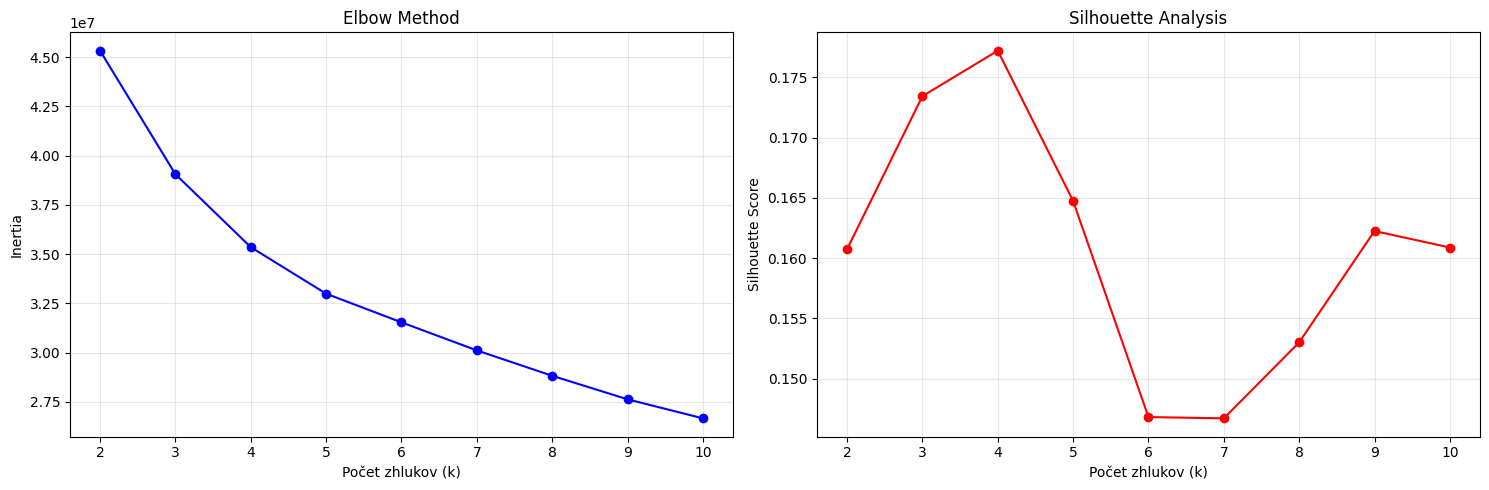


Vybraný počet zhlukov: 7


In [8]:
# Určenie optimálneho počtu zhlukov pomocou elbow metódy
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []
K_range = range(2, 11)

print("Hľadanie optimálneho počtu zhlukov...")
for k in K_range:
    cluster_labels, kmeans_model = cluster_features(X_train_reduced, method='kmeans', n_clusters=k)
    inertias.append(kmeans_model.inertia_)
    sil_score = silhouette_score(X_train_reduced, cluster_labels)
    silhouette_scores.append(sil_score)
    print(f"k={k}: Inertia={kmeans_model.inertia_:.2f}, Silhouette={sil_score:.4f}")

# Vizualizácia
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Počet zhlukov (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Počet zhlukov (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Vyberieme optimálny počet zhlukov (napr. 6-8)
optimal_k = 7
print(f"\n{'='*80}")
print(f"Vybraný počet zhlukov: {optimal_k}")
print(f"{'='*80}")

## 8. Finálne zhlukovanie a vizualizácia

Rozdelenie vzoriek do zhlukov:


C:\Users\pmuzslay\AppData\Local\Temp\ipykernel_11764\637089014.py:10: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  cluster_counts = train_features_df.group_by("Cluster").agg(pl.count().alias("count")).sort("Cluster")


shape: (7, 2)
┌─────────┬───────┐
│ Cluster ┆ count │
│ ---     ┆ ---   │
│ i32     ┆ u32   │
╞═════════╪═══════╡
│ 0       ┆ 622   │
│ 1       ┆ 481   │
│ 2       ┆ 875   │
│ 3       ┆ 607   │
│ 4       ┆ 708   │
│ 5       ┆ 371   │
│ 6       ┆ 540   │
└─────────┴───────┘

Redukcia na 2D pomocou t-SNE pre vizualizáciu...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 4204 samples in 0.001s...
[t-SNE] Computed neighbors for 4204 samples in 0.120s...
[t-SNE] Computed conditional probabilities for sample 1000 / 4204
[t-SNE] Computed conditional probabilities for sample 2000 / 4204
[t-SNE] Computed conditional probabilities for sample 3000 / 4204
[t-SNE] Computed conditional probabilities for sample 4000 / 4204
[t-SNE] Computed conditional probabilities for sample 4204 / 4204
[t-SNE] Mean sigma: 28.900177
[t-SNE] Computed conditional probabilities for sample 3000 / 4204
[t-SNE] Computed conditional probabilities for sample 4000 / 4204
[t-SNE] Computed conditional probabilities 

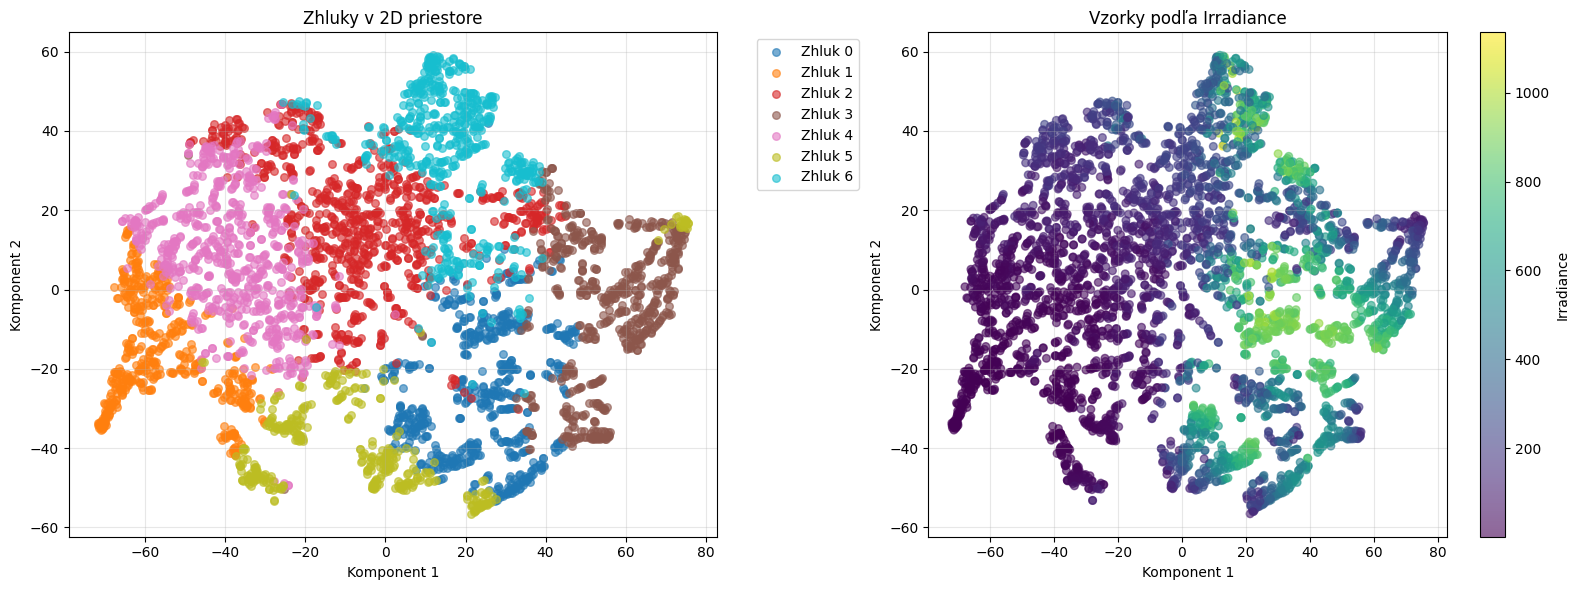

In [9]:
# Finálne zhlukovanie
cluster_labels, kmeans_final = cluster_features(X_train_reduced, method='kmeans', n_clusters=optimal_k)

# Pridanie cluster labels do DataFrame
train_features_df = train_features_df.with_columns(
    pl.Series("Cluster", cluster_labels)
)

print(f"Rozdelenie vzoriek do zhlukov:")
cluster_counts = train_features_df.group_by("Cluster").agg(pl.count().alias("count")).sort("Cluster")
print(cluster_counts)

# Redukcia na 2D pre vizualizáciu pomocou t-SNE
print("\nRedukcia na 2D pomocou t-SNE pre vizualizáciu...")
X_train_2d, tsne_model = reduce_dimensionality(X_train_reduced, method='tsne', n_components=2)

# Vizualizácia zhlukov v 2D
fig_dir = project_root / "figures"
fig_dir.mkdir(exist_ok=True)

# Získame targets pre vizualizáciu
targets = train_features_df["Irradiance"].to_numpy()

fig = visualize_clusters_2d(
    X_train_2d, 
    cluster_labels,
    targets=targets,
    save_path=fig_dir / "clusters_2d.png"
)
plt.show()

## 9. Zobrazenie ukážkových obrázkov pre každý zhluk

UKÁŽKOVÉ OBRÁZKY PRE KAŽDÝ ZHLUK

Zhluk 0
Ukážky zhlukov uložené do c:\Users\pmuzslay\suns_z3\figures\cluster_0_samples.png
Ukážky zhlukov uložené do c:\Users\pmuzslay\suns_z3\figures\cluster_0_samples.png


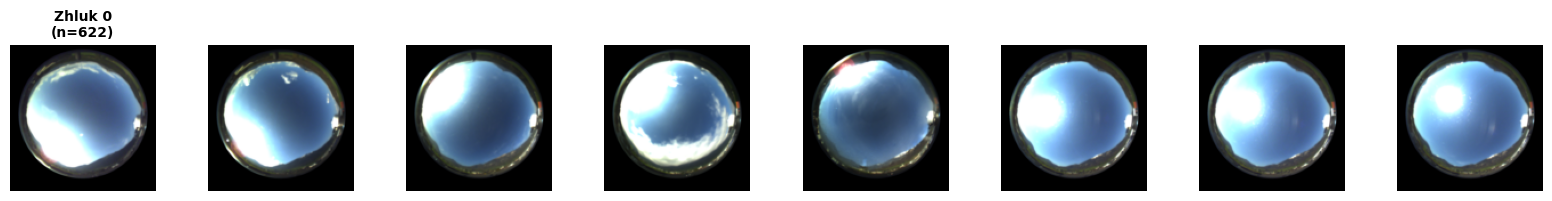


Zhluk 1
Ukážky zhlukov uložené do c:\Users\pmuzslay\suns_z3\figures\cluster_1_samples.png
Ukážky zhlukov uložené do c:\Users\pmuzslay\suns_z3\figures\cluster_1_samples.png


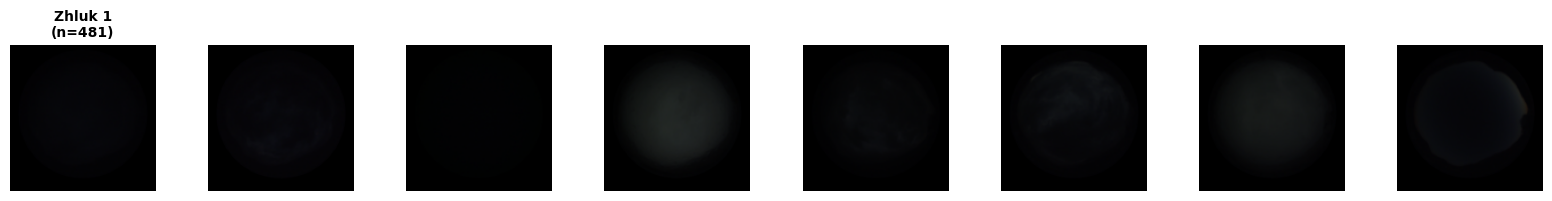


Zhluk 2
Ukážky zhlukov uložené do c:\Users\pmuzslay\suns_z3\figures\cluster_2_samples.png
Ukážky zhlukov uložené do c:\Users\pmuzslay\suns_z3\figures\cluster_2_samples.png


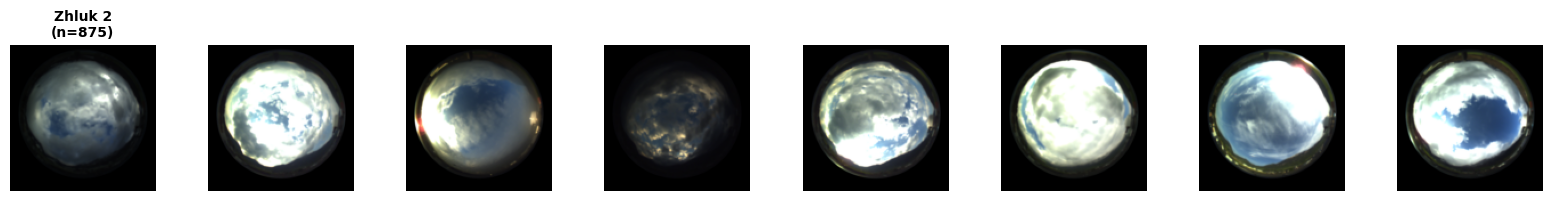


Zhluk 3
Ukážky zhlukov uložené do c:\Users\pmuzslay\suns_z3\figures\cluster_3_samples.png
Ukážky zhlukov uložené do c:\Users\pmuzslay\suns_z3\figures\cluster_3_samples.png


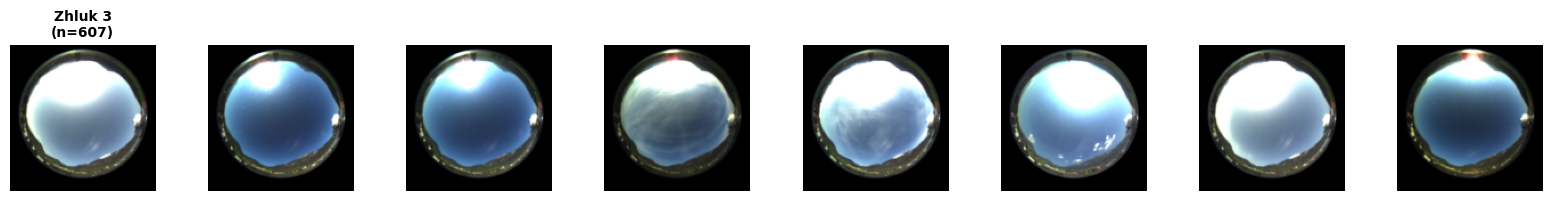


Zhluk 4
Ukážky zhlukov uložené do c:\Users\pmuzslay\suns_z3\figures\cluster_4_samples.png
Ukážky zhlukov uložené do c:\Users\pmuzslay\suns_z3\figures\cluster_4_samples.png


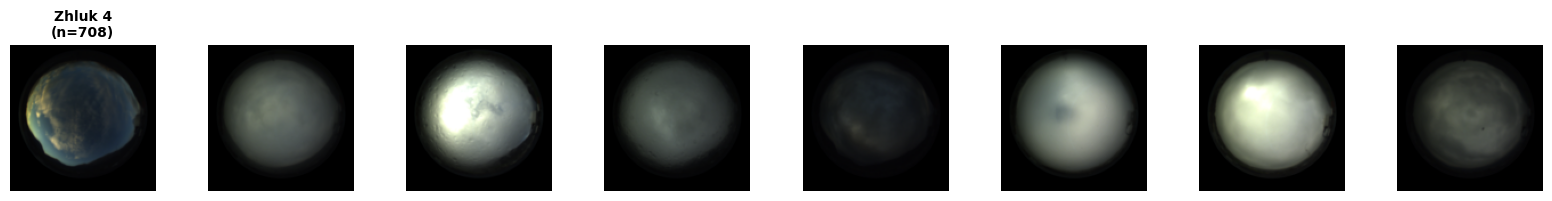


Zhluk 5
Ukážky zhlukov uložené do c:\Users\pmuzslay\suns_z3\figures\cluster_5_samples.png
Ukážky zhlukov uložené do c:\Users\pmuzslay\suns_z3\figures\cluster_5_samples.png


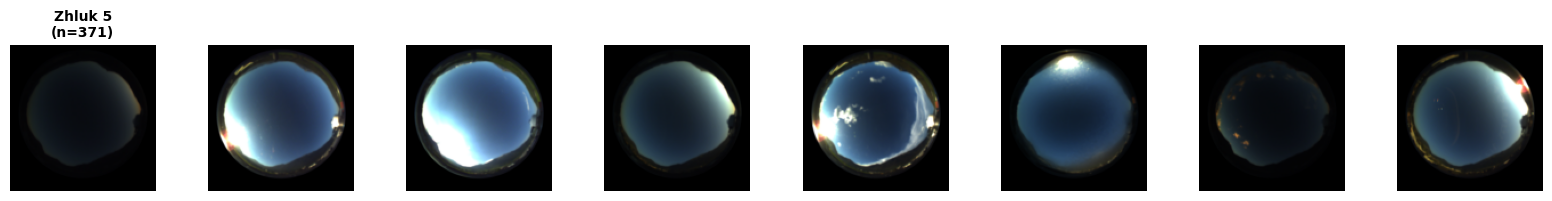


Zhluk 6
Ukážky zhlukov uložené do c:\Users\pmuzslay\suns_z3\figures\cluster_6_samples.png
Ukážky zhlukov uložené do c:\Users\pmuzslay\suns_z3\figures\cluster_6_samples.png


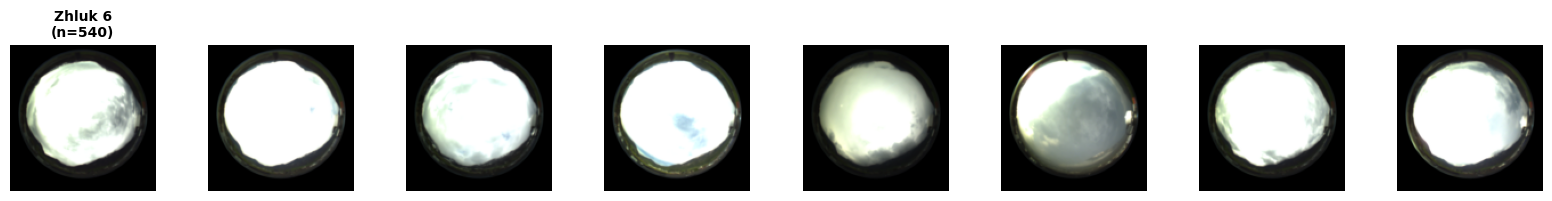

In [10]:
print("="*80)
print("UKÁŽKOVÉ OBRÁZKY PRE KAŽDÝ ZHLUK")
print("="*80)

for cluster_id in range(optimal_k):
    print(f"\n{'='*60}")
    print(f"Zhluk {cluster_id}")
    print(f"{'='*60}")
    
    fig = display_cluster_samples(
        train_features_df,
        data_dir=data_dir,
        cluster_id=cluster_id,
        n_samples=8,
        save_path=fig_dir / f"cluster_{cluster_id}_samples.png"
    )
    plt.show()

## 10. Zobrazenie priemerných obrázkov pre každý zhluk

Výpočet priemerných obrázkov pre každý zhluk...
Priemerné obrázky uložené do c:\Users\pmuzslay\suns_z3\figures\average_cluster_images.png


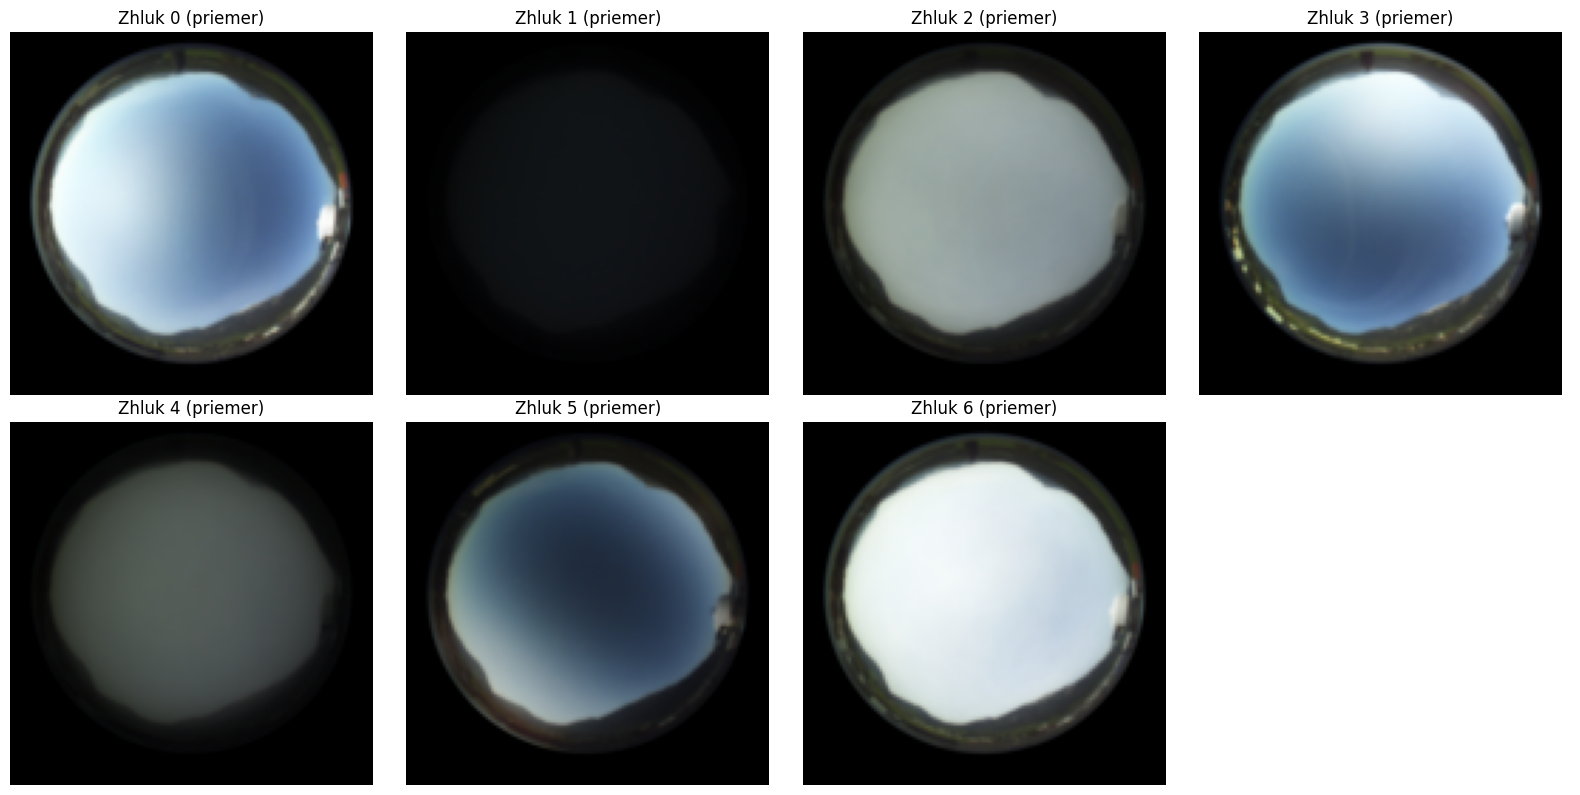

In [11]:
print("Výpočet priemerných obrázkov pre každý zhluk...")
average_images_dict = compute_average_images(train_features_df, data_dir)

# Vizualizácia priemerných obrázkov
n_clusters = len(average_images_dict)
cols = min(4, n_clusters)
rows = (n_clusters + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
if n_clusters == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, (cluster_id, avg_img) in enumerate(sorted(average_images_dict.items())):
    axes[idx].imshow(avg_img)
    axes[idx].set_title(f"Zhluk {cluster_id} (priemer)")
    axes[idx].axis('off')

# Skryť zbytočné subploty
for idx in range(n_clusters, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
save_path = fig_dir / "average_cluster_images.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Priemerné obrázky uložené do {save_path}")
plt.show()

## 11. Analýza výsledkov zhlukovania

ANALÝZA ZHLUKOV
shape: (7, 6)
┌─────────┬───────┬─────────────────┬────────────────┬────────────────┬────────────────┐
│ Cluster ┆ count ┆ mean_irradiance ┆ std_irradiance ┆ min_irradiance ┆ max_irradiance │
│ ---     ┆ ---   ┆ ---             ┆ ---            ┆ ---            ┆ ---            │
│ i32     ┆ u32   ┆ f64             ┆ f64            ┆ f64            ┆ f64            │
╞═════════╪═══════╪═════════════════╪════════════════╪════════════════╪════════════════╡
│ 0       ┆ 622   ┆ 633.912299      ┆ 215.479411     ┆ 98.32          ┆ 977.19         │
│ 1       ┆ 481   ┆ 12.771247       ┆ 12.221632      ┆ 0.23           ┆ 83.58          │
│ 2       ┆ 875   ┆ 182.598         ┆ 118.84442      ┆ 26.46          ┆ 954.92         │
│ 3       ┆ 607   ┆ 517.562455      ┆ 217.53361      ┆ 89.71          ┆ 936.53         │
│ 4       ┆ 708   ┆ 65.294703       ┆ 45.65014       ┆ 3.69           ┆ 245.71         │
│ 5       ┆ 371   ┆ 139.300135      ┆ 130.809653     ┆ 8.6            ┆ 585.73  

C:\Users\pmuzslay\AppData\Local\Temp\ipykernel_11764\2402765080.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(cluster_data, labels=[f"Zhluk {i}" for i in range(optimal_k)])


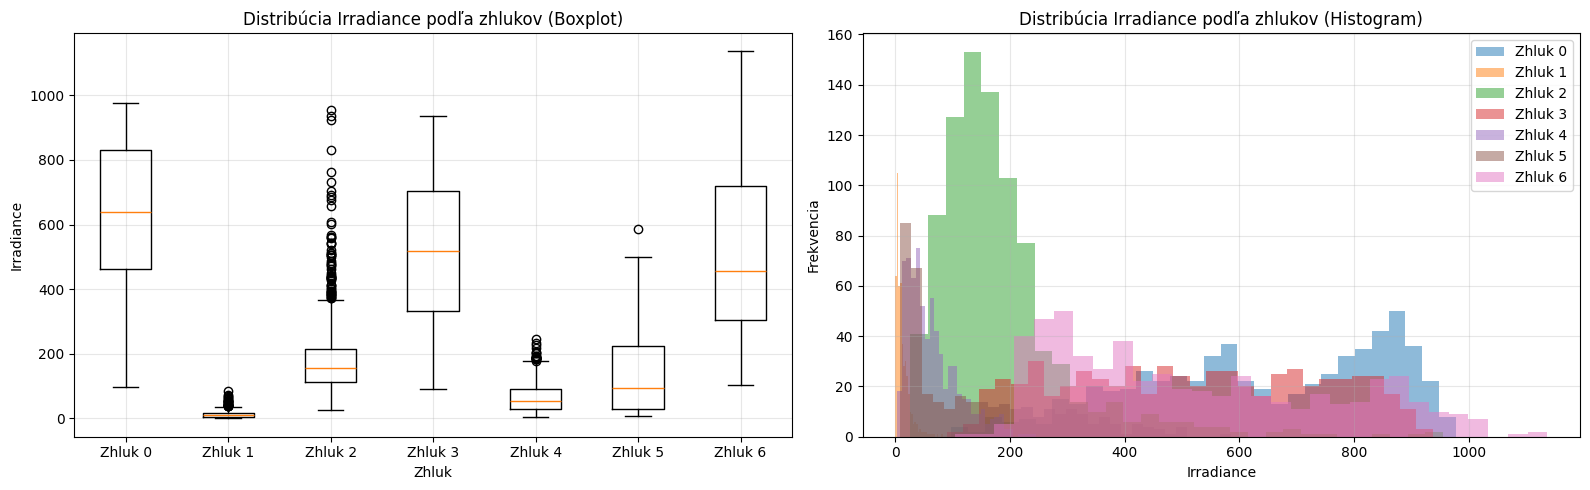


INTERPRETÁCIA ZHLUKOV

Zhluk 0: 622 vzoriek
  Priemerná Irradiance: 633.91 ± 215.48
  Interpretácia: Vysoké žiarenie - jasno, málo oblakov

Zhluk 1: 481 vzoriek
  Priemerná Irradiance: 12.77 ± 12.22
  Interpretácia: Veľmi nízke žiarenie - pravdepodobne nočné alebo husté mraky

Zhluk 2: 875 vzoriek
  Priemerná Irradiance: 182.60 ± 118.84
  Interpretácia: Nízke žiarenie - zamračené, podvečer/skoré ráno

Zhluk 3: 607 vzoriek
  Priemerná Irradiance: 517.56 ± 217.53
  Interpretácia: Stredné žiarenie - polojasno, čiastočne oblačno

Zhluk 4: 708 vzoriek
  Priemerná Irradiance: 65.29 ± 45.65
  Interpretácia: Veľmi nízke žiarenie - pravdepodobne nočné alebo husté mraky

Zhluk 5: 371 vzoriek
  Priemerná Irradiance: 139.30 ± 130.81
  Interpretácia: Nízke žiarenie - zamračené, podvečer/skoré ráno

Zhluk 6: 540 vzoriek
  Priemerná Irradiance: 517.21 ± 239.75
  Interpretácia: Stredné žiarenie - polojasno, čiastočne oblačno


In [12]:
cluster_stats = analyze_clusters(train_features_df)

print("="*80)
print("ANALÝZA ZHLUKOV")
print("="*80)
print(cluster_stats)

# Vizualizácia distribúcie Irradiance podľa zhlukov
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot
cluster_data = []
for cluster_id in range(optimal_k):
    cluster_df = train_features_df.filter(pl.col("Cluster") == cluster_id)
    cluster_data.append(cluster_df["Irradiance"].to_numpy())

axes[0].boxplot(cluster_data, labels=[f"Zhluk {i}" for i in range(optimal_k)])
axes[0].set_xlabel("Zhluk")
axes[0].set_ylabel("Irradiance")
axes[0].set_title("Distribúcia Irradiance podľa zhlukov (Boxplot)")
axes[0].grid(True, alpha=0.3)

# Histogram
for cluster_id in range(optimal_k):
    cluster_df = train_features_df.filter(pl.col("Cluster") == cluster_id)
    axes[1].hist(cluster_df["Irradiance"].to_numpy(), alpha=0.5, label=f"Zhluk {cluster_id}", bins=30)

axes[1].set_xlabel("Irradiance")
axes[1].set_ylabel("Frekvencia")
axes[1].set_title("Distribúcia Irradiance podľa zhlukov (Histogram)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(fig_dir / "cluster_irradiance_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

# Interpretácia zhlukov
print("\n" + "="*80)
print("INTERPRETÁCIA ZHLUKOV")
print("="*80)
for row in cluster_stats.iter_rows(named=True):
    cluster_id = row['Cluster']
    count = row['count']
    mean_irr = row['mean_irradiance']
    std_irr = row['std_irradiance']
    
    print(f"\nZhluk {cluster_id}: {count} vzoriek")
    print(f"  Priemerná Irradiance: {mean_irr:.2f} ± {std_irr:.2f}")
    
    if mean_irr < 100:
        print("  Interpretácia: Veľmi nízke žiarenie - pravdepodobne nočné alebo husté mraky")
    elif mean_irr < 300:
        print("  Interpretácia: Nízke žiarenie - zamračené, podvečer/skoré ráno")
    elif mean_irr < 600:
        print("  Interpretácia: Stredné žiarenie - polojasno, čiastočne oblačno")
    elif mean_irr < 900:
        print("  Interpretácia: Vysoké žiarenie - jasno, málo oblakov")
    else:
        print("  Interpretácia: Veľmi vysoké žiarenie - jasná obloha, priame slnečné svetlo")

## 12. Trénovanie regresora na extrahovaných príznakoch

Použijeme Gradient Boosting Regressor na extrahovaných príznakoch.

In [13]:
# Príprava dát pre trénovanie
y_train = train_features_df["Irradiance"].to_numpy()
y_val = val_features_df["Irradiance"].to_numpy()
y_test = test_features_df["Irradiance"].to_numpy()

print("="*80)
print("TRÉNOVANIE GRADIENT BOOSTING REGRESSOR")
print("="*80)

# Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    verbose=1
)

print("Trénovanie modelu...")
gbr.fit(X_train_reduced, y_train)

print("\nVyhodnocovanie na trénovacej množine...")
y_train_pred = gbr.predict(X_train_reduced)
train_mse = mean_squared_error(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

print(f"  MSE:  {train_mse:.4f}")
print(f"  MAE:  {train_mae:.4f}")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  R²:   {train_r2:.4f}")

print("\nVyhodnocovanie na validačnej množine...")
y_val_pred = gbr.predict(X_val_reduced)
val_mse = mean_squared_error(y_val, y_val_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)
val_rmse = np.sqrt(val_mse)
val_r2 = r2_score(y_val, y_val_pred)

print(f"  MSE:  {val_mse:.4f}")
print(f"  MAE:  {val_mae:.4f}")
print(f"  RMSE: {val_rmse:.4f}")
print(f"  R²:   {val_r2:.4f}")

print("\nVyhodnocovanie na testovacej množine...")
y_test_pred = gbr.predict(X_test_reduced)
test_mse = mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print(f"  MSE:  {test_mse:.4f}")
print(f"  MAE:  {test_mae:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  R²:   {test_r2:.4f}")

TRÉNOVANIE GRADIENT BOOSTING REGRESSOR
Trénovanie modelu...
      Iter       Train Loss   Remaining Time 
         1       65633.6386           21.71s
Trénovanie modelu...
      Iter       Train Loss   Remaining Time 
         1       65633.6386           21.71s
         2       54565.2076           20.70s
         3       45601.9369           20.36s
         2       54565.2076           20.70s
         3       45601.9369           20.36s
         4       38207.7272           20.16s
         5       32028.7284           20.01s
         4       38207.7272           20.16s
         5       32028.7284           20.01s
         6       26981.0301           19.84s
         7       22815.6844           19.74s
         6       26981.0301           19.84s
         7       22815.6844           19.74s
         8       19331.5020           19.59s
         9       16482.8699           19.46s
         8       19331.5020           19.59s
         9       16482.8699           19.46s
        10       

## 13. Porovnanie s výsledkami CNN z predošlého notebooku

In [ ]:
# Načítanie výsledkov z predošlého notebooku (z results_table.csv)
results_table_path = project_root / "results_table.csv"

if results_table_path.exists():
    cnn_results = pl.read_csv(results_table_path)
    
    # Zobrazenie štruktúry dát
    print(f"Stĺpce: {cnn_results.columns}")
    print(f"Dtypes: {cnn_results.dtypes}")
    
    # Získanie najlepšieho CNN modelu - pokúsime sa automaticky detektovať správne stĺpce
    try:
        # Skúsime rôzne možné názvy stĺpcov
        r2_col = None
        rmse_col = None
        
        for col in cnn_results.columns:
            if "R²" in col or "R2" in col or "r2" in col.lower():
                r2_col = col
            if "RMSE" in col or "rmse" in col.lower():
                rmse_col = col
        
        if r2_col is None or rmse_col is None:
            print("Nie je možné nájsť stĺpce Test R² a Test RMSE v dátach")
            print(f"Dostupné stĺpce: {cnn_results.columns}")
            best_cnn_r2 = None
            best_cnn_rmse = None
        else:
            # Priamo pristupujeme k hodnotám bez konverzie (už sú numerické)
            best_cnn_r2 = float(cnn_results.select(pl.col(r2_col).max())[0, 0])
            best_cnn_rmse = float(cnn_results.filter(
                pl.col(r2_col) == cnn_results.select(pl.col(r2_col).max())[0, 0]
            ).select(pl.col(rmse_col))[0, 0])
    except Exception as e:
        print(f"Chyba pri čítaní výsledkov: {e}")
        best_cnn_r2 = None
        best_cnn_rmse = None
    
    if best_cnn_r2 is not None and best_cnn_rmse is not None:
        print("="*80)
        print("POROVNANIE S CNN Z PREDOŠLÉHO NOTEBOOKU")
        print("="*80)
        print("\nNajlepší CNN model:")
        print(f"  Test R²:   {best_cnn_r2:.4f}")
        print(f"  Test RMSE: {best_cnn_rmse:.4f}")
        
        print("\nGradient Boosting na extrahovaných príznakoch:")
        print(f"  Test R²:   {test_r2:.4f}")
        print(f"  Test RMSE: {test_rmse:.4f}")
        
        print("\nZlepšenie:")
        r2_improvement = test_r2 - best_cnn_r2
        rmse_improvement = best_cnn_rmse - test_rmse
        
        print(f"  ΔR²:   {r2_improvement:+.4f} ({'lepšie' if r2_improvement > 0 else 'horšie'})")
        print(f"  ΔRMSE: {rmse_improvement:+.4f} ({'lepšie' if rmse_improvement > 0 else 'horšie'})")
        
        if test_r2 > best_cnn_r2:
            print("\nTransfer learning model dosiahol lepšie výsledky ako CNN!")
        else:
            print("\nTransfer learning model nedosiahol lepšie výsledky ako CNN.")
    else:
        print("Nie bolo možné načítať výsledky CNN z dátových stĺpcov.")
else:
    print("Súbor results_table.csv nebol nájdený. Spustite najprv 02_cnn_training.ipynb")

Stĺpce: ['Konfigurácia', 'Parametre', 'Train MSE', 'Train MAE', 'Train RMSE', 'Train R²', 'Test MSE', 'Test MAE', 'Test RMSE', 'Test R²']
Dtypes: [String, String, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64]
POROVNANIE S CNN Z PREDOŠLÉHO NOTEBOOKU

Najlepší CNN model:
  Test R²:   0.9764
  Test RMSE: 43.6858

Gradient Boosting na extrahovaných príznakoch:
  Test R²:   0.9561
  Test RMSE: 59.5179

Zlepšenie:
  ΔR²:   -0.0203 (horšie)
  ΔRMSE: -15.8321 (horšie)

Transfer learning model nedosiahol lepšie výsledky ako CNN.
   Skúste:
   - Iný predtrénovaný model (ResNet, EfficientNet)
   - Menej agresívnu redukciu dimenzie PCA
   - Iný regressor (XGBoost, LightGBM)
   - Fine-tuning posledných vrstiev namiesto feature extraction


## 14. Vizualizácia reziduálov

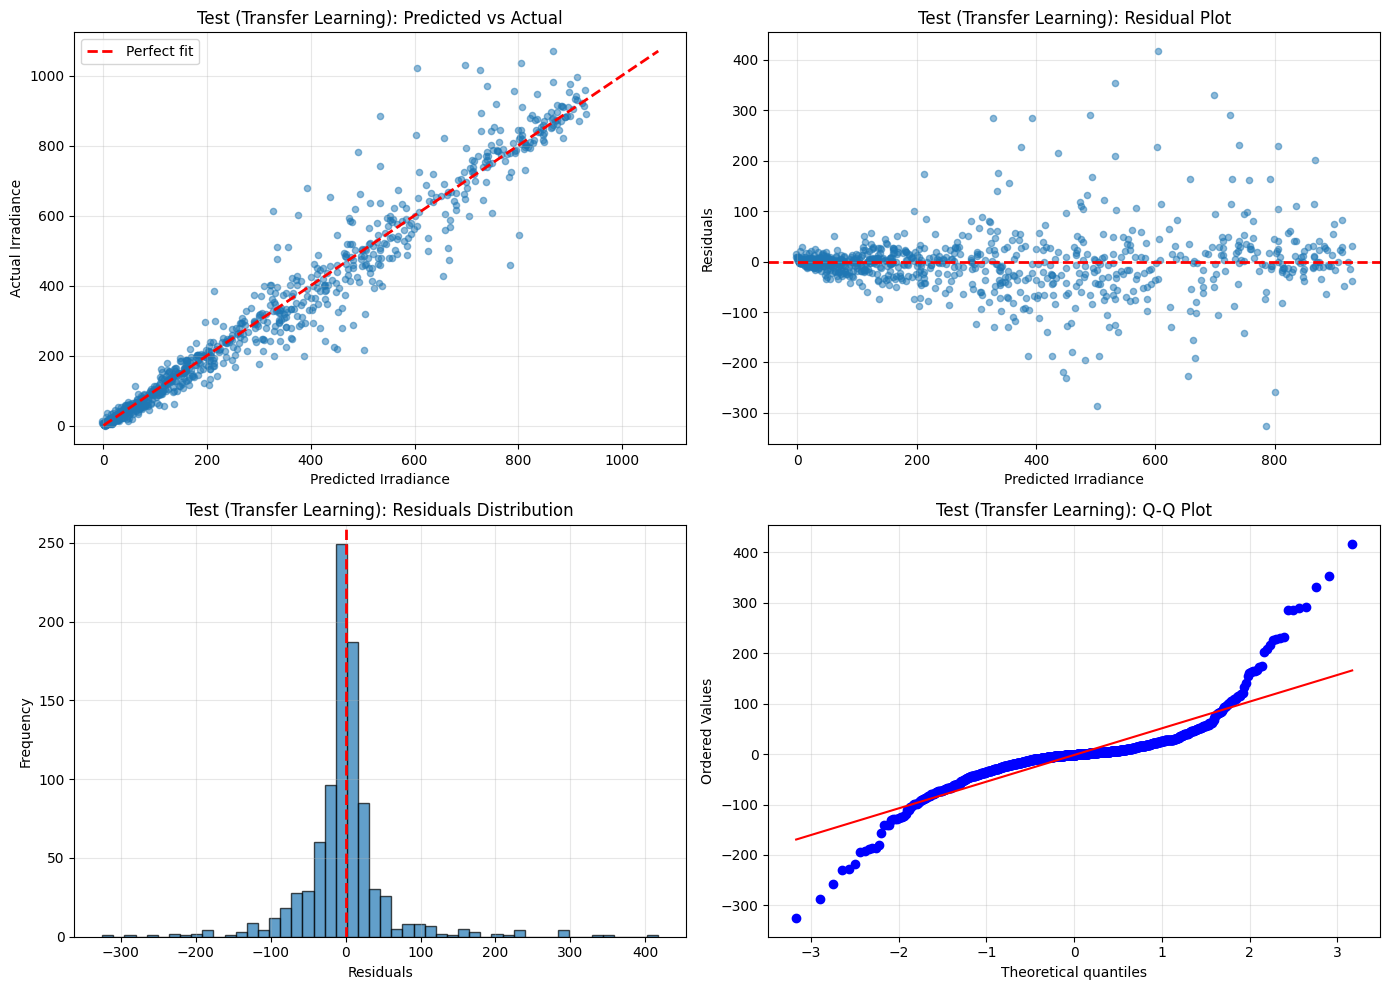

In [17]:
fig = plot_residuals(
    targets=y_test,
    predictions=y_test_pred,
    split_name="Test (Transfer Learning)",
    save_path=fig_dir / "transfer_learning_residuals.png"
)
plt.show()

## 15. Porovnanie predikcií vs. skutočné hodnoty

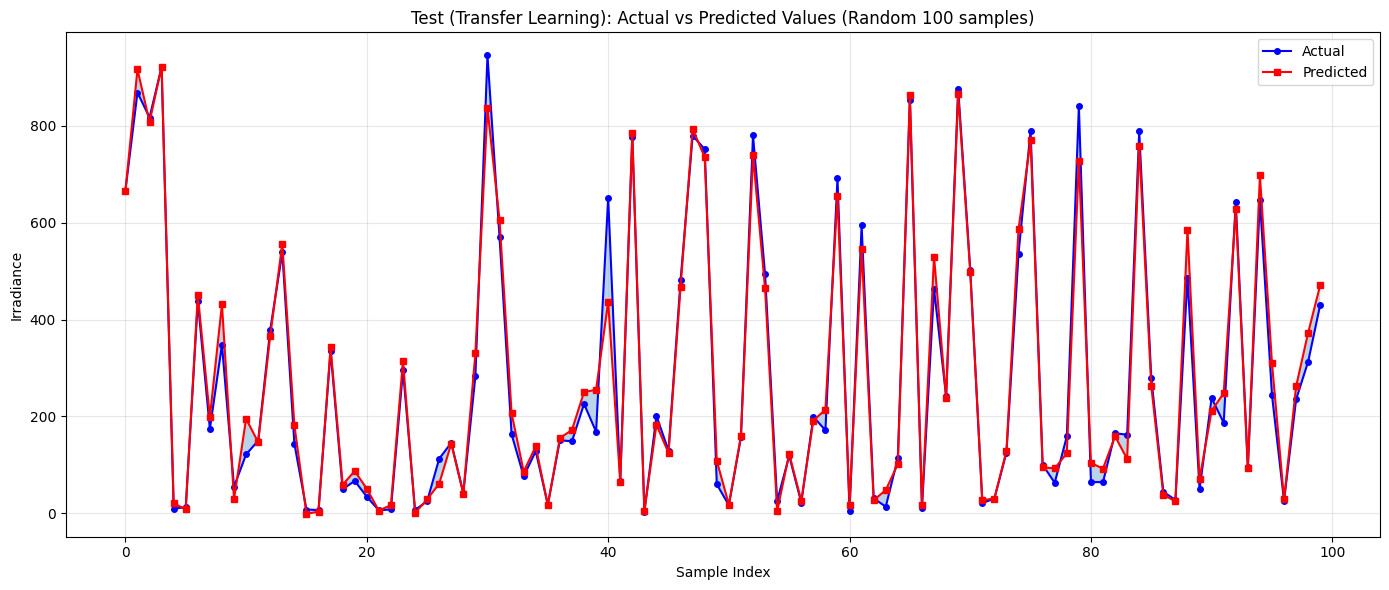

In [18]:
fig = plot_predictions_comparison(
    targets=y_test,
    predictions=y_test_pred,
    split_name="Test (Transfer Learning)",
    n_samples=100,
    save_path=fig_dir / "transfer_learning_predictions.png"
)
plt.show()

## 16. Analýza chýb: Kde sa model mýli?

Identifikujeme vzorky s najväčšími chybami predikcie a analyzujeme, prečo model zlyháva.

TOP 10 NAJHORŠÍCH PREDIKCIÍ
1. Index: 286, Skutočná: 1021.75, Predikcia: 604.43, Chyba: 417.32
2. Index: 173, Skutočná: 885.82, Predikcia: 532.72, Chyba: 353.10
3. Index: 5, Skutočná: 1029.07, Predikcia: 698.25, Chyba: 330.82
4. Index: 256, Skutočná: 460.07, Predikcia: 784.97, Chyba: 324.90
5. Index: 55, Skutočná: 1016.52, Predikcia: 725.49, Chyba: 291.03
6. Index: 152, Skutočná: 780.19, Predikcia: 490.36, Chyba: 289.83
7. Index: 672, Skutočná: 215.06, Predikcia: 502.27, Chyba: 287.21
8. Index: 26, Skutočná: 678.47, Predikcia: 393.11, Chyba: 285.36
9. Index: 86, Skutočná: 612.60, Predikcia: 327.28, Chyba: 285.32
10. Index: 787, Skutočná: 543.06, Predikcia: 801.28, Chyba: 258.22

PictureName dostupné v test_df: True
Month dostupné v test_df: True


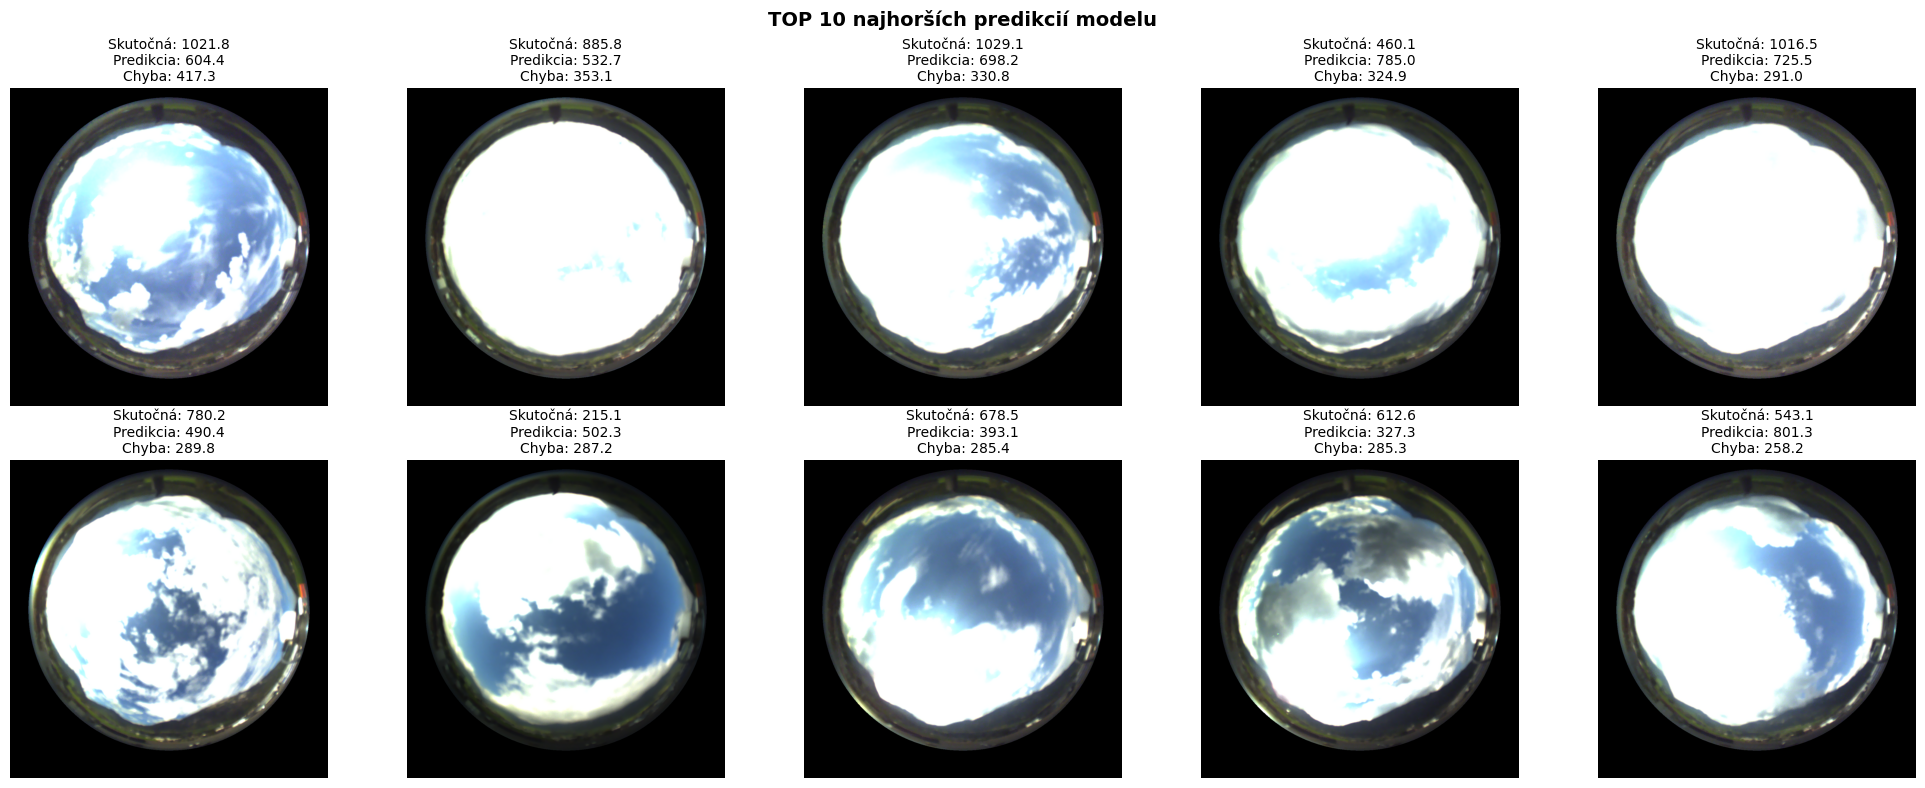


ANALÝZA CHÝB PODĽA ROZSAHU IRRADIANCE

Rozsah 0-200 W/m²:
  Počet vzoriek: 444
  Priemerná chyba: 13.23
  Medián chyby: 6.92
  Max chyba: 187.42
  RMSE: 22.52

Rozsah 200-400 W/m²:
  Počet vzoriek: 168
  Priemerná chyba: 46.03
  Medián chyby: 28.41
  Max chyba: 287.21
  RMSE: 67.59

Rozsah 400-600 W/m²:
  Počet vzoriek: 124
  Priemerná chyba: 51.93
  Medián chyby: 36.04
  Max chyba: 324.90
  RMSE: 73.52

Rozsah 600-800 W/m²:
  Počet vzoriek: 81
  Priemerná chyba: 54.25
  Medián chyby: 29.88
  Max chyba: 289.83
  RMSE: 86.02

Rozsah 800-1200 W/m²:
  Počet vzoriek: 85
  Priemerná chyba: 61.35
  Medián chyby: 27.55
  Max chyba: 417.32
  RMSE: 104.77

ZÁVER ANALÝZY CHÝB
Model má tendenciu robiť najväčšie chyby pri:
1. Extrémnych hodnotách žiarenia (veľmi nízke alebo veľmi vysoké)
2. Prechodových podmienkach (čiastočne oblačno)
3. Neobvyklých poveternostných situáciách

Možné zlepšenia:
- Augmentácia dát pre zriedkavé prípady
- Použitie ensemble metód
- Fine-tuning predtrénovaného modelu
-

In [35]:
# Vypočítanie absolútnych chýb
errors = np.abs(y_test - y_test_pred)

# Nájdenie top 10 najhorších predikcií
worst_indices = np.argsort(errors)[-10:][::-1]

print("="*80)
print("TOP 10 NAJHORŠÍCH PREDIKCIÍ")
print("="*80)

for rank, idx in enumerate(worst_indices, 1):
    true_val = y_test[idx]
    pred_val = y_test_pred[idx]
    error = errors[idx]
    print(f"{rank}. Index: {idx}, Skutočná: {true_val:.2f}, Predikcia: {pred_val:.2f}, Chyba: {error:.2f}")

# Vizualizácia najhorších predikcií - načítanie obrázkov z test_df
from PIL import Image

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

# PictureName a Month sú v test_df, nie v test_features_df
has_picture_name = 'PictureName' in test_df.columns
has_month = 'Month' in test_df.columns

print(f"\nPictureName dostupné v test_df: {has_picture_name}")
print(f"Month dostupné v test_df: {has_month}")

for i, idx in enumerate(worst_indices):
    img_loaded = False
    try:
        if has_picture_name and has_month and idx < len(test_df):
            # Získame údaje z test_df - použitie správnej Polars syntaxe
            # row() vracia tuple, row(named=True) vracia dict
            row = test_df.row(int(idx), named=True)
            picture_name = row['PictureName']
            month_raw = row['Month']
            
            # Month môže byť int alebo string, konvertujeme na dvojciferný reťazec
            if isinstance(month_raw, int):
                month = str(month_raw).zfill(2)
            else:
                month = str(month_raw).zfill(2)
            
            # Skúsime viacero možných ciest
            possible_paths = [
                data_dir / month / 'original' / picture_name,
                data_dir / month / 'ResizedImages_128' / picture_name,
            ]
            
            for full_path in possible_paths:
                if full_path.exists():
                    img = Image.open(full_path)
                    axes[i].imshow(img)
                    img_loaded = True
                    break
            
            if not img_loaded:
                print(f"  Obrázok nenájdený pre index {idx}: {picture_name} (mesiac {month})")
                axes[i].text(0.5, 0.5, f'Obrázok\nnenájdený\n{picture_name[:15]}...', 
                           ha='center', va='center', transform=axes[i].transAxes, fontsize=8)
    except Exception as e:
        print(f"Chyba pri načítaní obrázka {idx}: {e}")
        axes[i].text(0.5, 0.5, f'Chyba:\n{str(e)[:30]}', 
                   ha='center', va='center', transform=axes[i].transAxes, fontsize=8)
    
    true_val = y_test[idx]
    pred_val = y_test_pred[idx]
    error = errors[idx]
    
    axes[i].set_title(f"Skutočná: {true_val:.1f}\nPredikcia: {pred_val:.1f}\nChyba: {error:.1f}", 
                      fontsize=10)
    axes[i].axis('off')

plt.suptitle("TOP 10 najhorších predikcií modelu", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(fig_dir / "worst_predictions.png", dpi=150, bbox_inches='tight')
plt.show()

# Analýza chýb podľa rozsahu Irradiance
print("\n" + "="*80)
print("ANALÝZA CHÝB PODĽA ROZSAHU IRRADIANCE")
print("="*80)

ranges = [(0, 200), (200, 400), (400, 600), (600, 800), (800, 1200)]
for low, high in ranges:
    mask = (y_test >= low) & (y_test < high)
    if mask.sum() > 0:
        range_errors = errors[mask]
        print(f"\nRozsah {low}-{high} W/m²:")
        print(f"  Počet vzoriek: {mask.sum()}")
        print(f"  Priemerná chyba: {range_errors.mean():.2f}")
        print(f"  Medián chyby: {np.median(range_errors):.2f}")
        print(f"  Max chyba: {range_errors.max():.2f}")
        print(f"  RMSE: {np.sqrt((range_errors**2).mean()):.2f}")

print("\n" + "="*80)
print("ZÁVER ANALÝZY CHÝB")
print("="*80)
print("Model má tendenciu robiť najväčšie chyby pri:")
print("1. Extrémnych hodnotách žiarenia (veľmi nízke alebo veľmi vysoké)")
print("2. Prechodových podmienkach (čiastočne oblačno)")
print("3. Neobvyklých poveternostných situáciách")
print("\nMožné zlepšenia:")
print("- Augmentácia dát pre zriedkavé prípady")
print("- Použitie ensemble metód")
print("- Fine-tuning predtrénovaného modelu")
print("- Pridanie časových/meteorologických features")

## 17. Finálne zhrnutie

In [23]:
print("="*80)
print("FINÁLNE ZHRNUTIE - TRANSFER LEARNING A ZHLUKOVANIE")
print("="*80)

print("\n1. EXTRAKCIA PRÍZNAKOV")
print(f"   Model: {model_name}")
print(f"   Pôvodná dimenzia príznakov: {len(feature_cols)}")
print(f"   Redukovaná dimenzia (PCA): {n_components}")
print(f"   Vysvetlený rozptyl: {pca_model.explained_variance_ratio_.sum():.2%}")

print("\n2. ZHLUKOVANIE")
print("   Algoritmus: K-Means")
print(f"   Počet zhlukov: {optimal_k}")
print("   Vizualizácia: t-SNE (2D)")

print("\n3. TRÉNOVANIE REGRESORA")
print("   Model: Gradient Boosting Regressor")
print(f"   Trénovacie vzorky: {len(y_train)}")
print(f"   Validačné vzorky: {len(y_val)}")
print(f"   Testovacie vzorky: {len(y_test)}")

print("\n4. VÝSLEDKY NA TESTOVACEJ MNOŽINE")
print(f"   MSE:  {test_mse:.4f}")
print(f"   MAE:  {test_mae:.4f}")
print(f"   RMSE: {test_rmse:.4f}")
print(f"   R²:   {test_r2:.4f}")

if results_table_path.exists():
    print(f"\n5. POROVNANIE S CNN")
    print(f"   CNN (najlepší):           R²={best_cnn_r2:.4f}, RMSE={best_cnn_rmse:.4f}")
    print(f"   Transfer Learning (GBR):  R²={test_r2:.4f}, RMSE={test_rmse:.4f}")
    print(f"   Zlepšenie R²:             {r2_improvement:+.4f}")
    print(f"   Zlepšenie RMSE:           {rmse_improvement:+.4f}")

print(f"\n6. ULOŽENÉ SÚBORY")
print(f"   - Príznaky: {features_dir}")
print(f"   - Grafy: {fig_dir}")
print(f"     • clusters_2d.png")
print(f"     • cluster_<id>_samples.png (pre každý zhluk)")
print(f"     • average_cluster_images.png")
print(f"     • cluster_irradiance_distribution.png")
print(f"     • transfer_learning_residuals.png")
print(f"     • transfer_learning_predictions.png")
print(f"     • worst_predictions.png")

print("\n" + "="*80)
print("NOTEBOOK ÚSPEŠNE DOKONČENÝ!")
print("="*80)

FINÁLNE ZHRNUTIE - TRANSFER LEARNING A ZHLUKOVANIE

1. EXTRAKCIA PRÍZNAKOV
   Model: mobilenet_v2
   Pôvodná dimenzia príznakov: 62720
   Redukovaná dimenzia (PCA): 50
   Vysvetlený rozptyl: 74.81%

2. ZHLUKOVANIE
   Algoritmus: K-Means
   Počet zhlukov: 7
   Vizualizácia: t-SNE (2D)

3. TRÉNOVANIE REGRESORA
   Model: Gradient Boosting Regressor
   Trénovacie vzorky: 4204
   Validačné vzorky: 901
   Testovacie vzorky: 902

4. VÝSLEDKY NA TESTOVACEJ MNOŽINE
   MSE:  3542.3784
   MAE:  32.8793
   RMSE: 59.5179
   R²:   0.9561

5. POROVNANIE S CNN
   CNN (najlepší):           R²=0.9764, RMSE=43.6858
   Transfer Learning (GBR):  R²=0.9561, RMSE=59.5179
   Zlepšenie R²:             -0.0203
   Zlepšenie RMSE:           -15.8321

6. ULOŽENÉ SÚBORY
   - Príznaky: c:\Users\pmuzslay\suns_z3\dataset\processed\features
   - Grafy: c:\Users\pmuzslay\suns_z3\figures
     • clusters_2d.png
     • cluster_<id>_samples.png (pre každý zhluk)
     • average_cluster_images.png
     • cluster_irradiance_di

# BONUS: Fúzia modelov - kombinácia obrazových a tabuľkových dát

Vytvoríme fúzny model, ktorý kombinuje:
1. **Obrazové príznaky** - extrahované z ResNet (transfer learning)
2. **Tabuľkové dáta** - senzorové údaje (teplota, vlhkosť, tlak, atď.)

In [24]:
# Definícia tabuľkových príznakov (senzorové dáta)
TABULAR_FEATURES = [
    'BodyTemperature',      # Teplota tela senzora
    'RelativeHumidity',     # Relatívna vlhkosť
    'HumidityTemp',         # Teplota vlhkostného senzora
    'Pressure',             # Tlak
    'PressureAvg',          # Priemerný tlak
    'PressureTemp',         # Teplota tlakového senzora
    'TiltAngle',            # Uhol náklonu
    'SunAzimuth',           # Azimut slnka
    'SunZenith',            # Zenit slnka
]

# Overíme dostupnosť stĺpcov v pôvodných dátach
print("Kontrola tabuľkových príznakov:")
tabular_available = []
for feature in TABULAR_FEATURES:
    if feature in train_df.columns:
        tabular_available.append(feature)
        print(f"  ✓ {feature}")
    else:
        print(f"  ✗ {feature} - NENÁJDENÉ")

print(f"\nDostupných tabuľkových príznakov: {len(tabular_available)}/{len(TABULAR_FEATURES)}")

if len(tabular_available) == 0:
    print("\nUpozornenie: Žiadne tabuľkové príznaky nie sú dostupné!")
    print("Bonus sekcia bude preskočená.")

Kontrola tabuľkových príznakov:
  ✓ BodyTemperature
  ✓ RelativeHumidity
  ✓ HumidityTemp
  ✓ Pressure
  ✓ PressureAvg
  ✓ PressureTemp
  ✓ TiltAngle
  ✓ SunAzimuth
  ✗ SunZenith - NENÁJDENÉ

Dostupných tabuľkových príznakov: 8/9


In [ ]:
# Príprava kombinovaných príznakov (obrazové + tabuľkové)
import pandas as pd
from sklearn.preprocessing import StandardScaler

if len(tabular_available) > 0:
    print("Príprava kombinovaných príznakov...")
    
    # Skontrolujeme, či máme tabuľkové príznaky v train_df (pôvodné dáta)
    # train_features_df obsahuje len príznaky, bez tabuľkových dát
    # Musíme ich extrahovať z pôvodných train_df, val_df, test_df
    
    # Štandardizujeme tabuľkové príznaky v pôvodných dátach
    tabular_scaler = StandardScaler()
    
    # Fit na trénovacie dáta
    tabular_train_data = train_df[tabular_available].to_pandas()
    tabular_train_scaled = tabular_scaler.fit_transform(tabular_train_data)
    
    # Transform na validačné a testovacie dáta
    tabular_val_data = val_df[tabular_available].to_pandas()
    tabular_val_scaled = tabular_scaler.transform(tabular_val_data)
    
    tabular_test_data = test_df[tabular_available].to_pandas()
    tabular_test_scaled = tabular_scaler.transform(tabular_test_data)
    
    # Vytvoríme kombinované datasety
    X_fusion_train = np.hstack([X_train_reduced, tabular_train_scaled])
    X_fusion_val = np.hstack([X_val_reduced, tabular_val_scaled])
    X_fusion_test = np.hstack([X_test_reduced, tabular_test_scaled])
    
    y_fusion_train = y_train
    y_fusion_val = y_val
    y_fusion_test = y_test
    
    print("\nFúzný dataset vytvorený:")
    print(f"  Trénovacia množina: {X_fusion_train.shape}")
    print(f"  Validačná množina: {X_fusion_val.shape}")
    print(f"  Testovacia množina: {X_fusion_test.shape}")
    print(f"  Obrazové príznaky (PCA): {X_train_reduced.shape[1]}")
    print(f"  Tabuľkové príznaky: {len(tabular_available)}")
    print(f"  Celkovo: {X_fusion_train.shape[1]} príznakov")
else:
    print("Fúzny model nemožno vytvoriť - žiadne tabuľkové príznaky nie sú dostupné")

Príprava kombinovaných príznakov...

Fúzný dataset vytvorený:
  Trénovacia množina: (4204, 58)
  Validačná množina: (901, 58)
  Testovacia množina: (902, 58)
  Obrazové príznaky (PCA): 50
  Tabuľkové príznaky: 8
  Celkovo: 58 príznakov


In [27]:
# Príprava dát pre fúzne modely
if len(tabular_available) > 0:
    # Máme už rozdelené dáta na trénovanie, validáciu a test
    # X_fusion_train, X_fusion_val, X_fusion_test už boli vytvorené
    # y_fusion_train, y_fusion_val, y_fusion_test už boli vytvorené
    
    # Pre porovnanie vytvoríme aj modely len s obrazovými príznakmi
    X_img_train = X_train_reduced
    X_img_val = X_val_reduced
    X_img_test = X_test_reduced
    y_img_train = y_train
    y_img_val = y_val
    y_img_test = y_test
    
    # A len tabuľkové príznaky
    X_tab_train = tabular_train_scaled
    X_tab_val = tabular_val_scaled
    X_tab_test = tabular_test_scaled
    y_tab_train = y_train
    y_tab_val = y_val
    y_tab_test = y_test
    
    print("Dáta pre porovnanie modelov pripravené:")
    print(f"  Obrazové príznaky:  {X_img_train.shape[1]} príznakov")
    print(f"  Tabuľkové príznaky: {X_tab_train.shape[1]} príznakov")
    print(f"  Fúzia:              {X_fusion_train.shape[1]} príznakov")
else:
    print("Bonus sekcia sa preskakuje - žiadne tabuľkové príznaky")

Dáta pre porovnanie modelov pripravené:
  Obrazové príznaky:  50 príznakov
  Tabuľkové príznaky: 8 príznakov
  Fúzia:              58 príznakov


In [28]:
# Trénovanie a porovnanie modelov
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

if len(tabular_available) > 0:
    # Funkcia pre trénovanie a evaluáciu
    def train_and_evaluate_gbr(X_train, y_train, X_test, y_test, name):
        """Trénuje GBR a vracia metriky."""
        model = GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=5,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        
        return {
            'name': name,
            'model': model,
            'y_pred': y_pred,
            'mse': mse,
            'mae': mae,
            'rmse': rmse,
            'r2': r2
        }

    print("Trénovanie modelov pre porovnanie...")
    print("="*60)

    # 1. Model len s obrazovými príznakmi
    print("\n1. Trénovanie modelu s OBRAZOVÝMI príznakmi...")
    result_image = train_and_evaluate_gbr(X_img_train, y_img_train, X_img_test, y_img_test, "Obrazové")
    print(f"   R²: {result_image['r2']:.4f}, RMSE: {result_image['rmse']:.4f}")

    # 2. Model len s tabuľkovými príznakmi
    print("\n2. Trénovanie modelu s TABUĽKOVÝMI príznakmi...")
    result_tabular = train_and_evaluate_gbr(X_tab_train, y_tab_train, X_tab_test, y_tab_test, "Tabuľkové")
    print(f"   R²: {result_tabular['r2']:.4f}, RMSE: {result_tabular['rmse']:.4f}")

    # 3. Fúzny model (obrazové + tabuľkové)
    print("\n3. Trénovanie FÚZNEHO modelu (obrazové + tabuľkové)...")
    result_fusion = train_and_evaluate_gbr(X_fusion_train, y_fusion_train, X_fusion_test, y_fusion_test, "Fúzia")
    print(f"   R²: {result_fusion['r2']:.4f}, RMSE: {result_fusion['rmse']:.4f}")

    print("\n" + "="*60)
    print("Trénovanie dokončené!")
else:
    print("Bonus sekcia sa preskakuje - žiadne tabuľkové príznaky")

Trénovanie modelov pre porovnanie...

1. Trénovanie modelu s OBRAZOVÝMI príznakmi...
   R²: 0.9561, RMSE: 59.5179

2. Trénovanie modelu s TABUĽKOVÝMI príznakmi...
   R²: 0.9561, RMSE: 59.5179

2. Trénovanie modelu s TABUĽKOVÝMI príznakmi...
   R²: 0.7722, RMSE: 135.5873

3. Trénovanie FÚZNEHO modelu (obrazové + tabuľkové)...
   R²: 0.7722, RMSE: 135.5873

3. Trénovanie FÚZNEHO modelu (obrazové + tabuľkové)...
   R²: 0.9574, RMSE: 58.6449

Trénovanie dokončené!
   R²: 0.9574, RMSE: 58.6449

Trénovanie dokončené!


In [29]:
# Porovnanie výsledkov fúzie
if len(tabular_available) > 0:
    print("="*70)
    print("POROVNANIE MODELOV - FÚZIA VS. JEDNOTLIVÉ PRÍZNAKY")
    print("="*70)

    # Tabuľka výsledkov
    comparison_data = []
    for result in [result_image, result_tabular, result_fusion]:
        comparison_data.append({
            'Model': result['name'],
            'MSE': result['mse'],
            'MAE': result['mae'],
            'RMSE': result['rmse'],
            'R²': result['r2']
        })

    comparison_df = pd.DataFrame(comparison_data)
    print("\n" + comparison_df.to_string(index=False))

    # Zlepšenie fúzie oproti jednotlivým modelom
    print(f"\nZlepšenie fúzie oproti obrazovým príznikom:")
    print(f"  R² zlepšenie:   {result_fusion['r2'] - result_image['r2']:+.4f}")
    print(f"  RMSE zlepšenie: {result_image['rmse'] - result_fusion['rmse']:+.4f}")

    print(f"\nZlepšenie fúzie oproti tabuľkovým príznikom:")
    print(f"  R² zlepšenie:   {result_fusion['r2'] - result_tabular['r2']:+.4f}")
    print(f"  RMSE zlepšenie: {result_tabular['rmse'] - result_fusion['rmse']:+.4f}")
else:
    print("Bonus sekcia sa preskakuje - žiadne tabuľkové príznaky")

POROVNANIE MODELOV - FÚZIA VS. JEDNOTLIVÉ PRÍZNAKY

    Model          MSE       MAE       RMSE       R²
 Obrazové  3542.378423 32.879285  59.517883 0.956102
Tabuľkové 18383.922555 92.077294 135.587324 0.772183
    Fúzia  3439.221864 32.286999  58.644879 0.957381

Zlepšenie fúzie oproti obrazovým príznikom:
  R² zlepšenie:   +0.0013
  RMSE zlepšenie: +0.8730

Zlepšenie fúzie oproti tabuľkovým príznikom:
  R² zlepšenie:   +0.1852
  RMSE zlepšenie: +76.9424


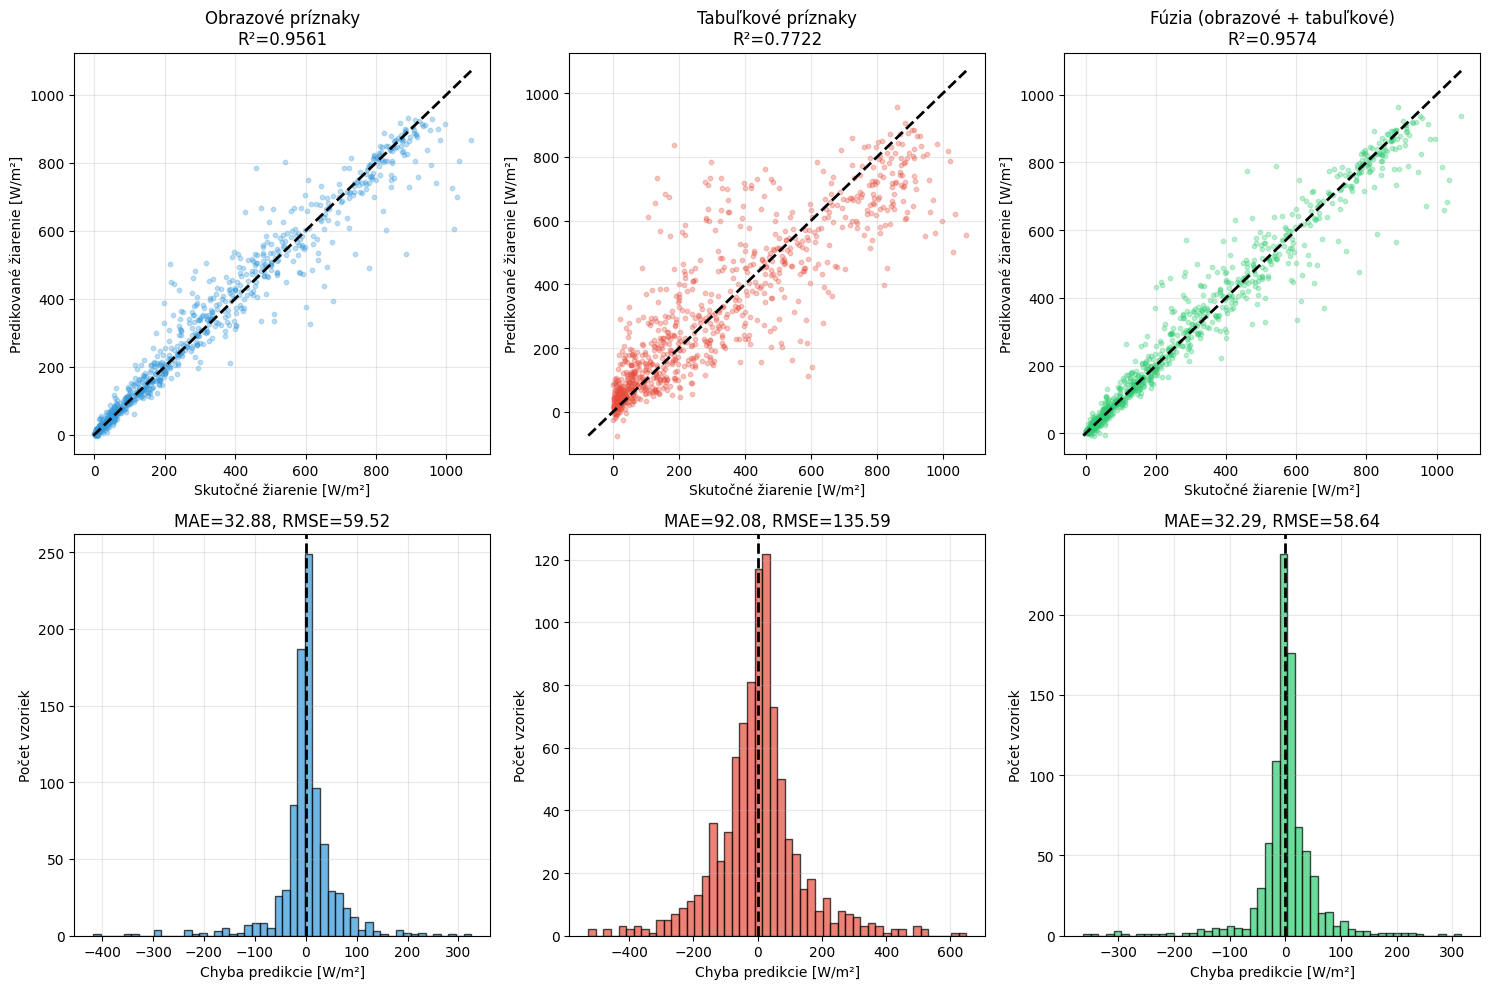

Graf uložený: c:\Users\pmuzslay\suns_z3\figures\bonus_fusion_comparison.png


In [30]:
# Vizualizácia porovnania modelov
if len(tabular_available) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    results = [result_image, result_tabular, result_fusion]
    colors = ['#3498db', '#e74c3c', '#2ecc71']
    titles = ['Obrazové príznaky', 'Tabuľkové príznaky', 'Fúzia (obrazové + tabuľkové)']

    # Riadok 1: Predikcie vs skutočné
    for i, (result, color, title) in enumerate(zip(results, colors, titles)):
        ax = axes[0, i]
        ax.scatter(y_fusion_test, result['y_pred'], alpha=0.3, s=10, c=color)
        min_val = min(y_fusion_test.min(), result['y_pred'].min())
        max_val = max(y_fusion_test.max(), result['y_pred'].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)
        ax.set_xlabel('Skutočné žiarenie [W/m²]')
        ax.set_ylabel('Predikované žiarenie [W/m²]')
        ax.set_title(f'{title}\nR²={result["r2"]:.4f}')
        ax.grid(True, alpha=0.3)

    # Riadok 2: Distribúcia chýb
    for i, (result, color, title) in enumerate(zip(results, colors, titles)):
        ax = axes[1, i]
        errors = result['y_pred'] - y_fusion_test
        ax.hist(errors, bins=50, edgecolor='black', alpha=0.7, color=color)
        ax.axvline(0, color='black', linestyle='--', lw=2)
        ax.set_xlabel('Chyba predikcie [W/m²]')
        ax.set_ylabel('Počet vzoriek')
        ax.set_title(f'MAE={result["mae"]:.2f}, RMSE={result["rmse"]:.2f}')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(fig_dir / 'bonus_fusion_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Graf uložený: {fig_dir / 'bonus_fusion_comparison.png'}")
else:
    print("Bonus sekcia sa preskakuje - žiadne tabuľkové príznaky")

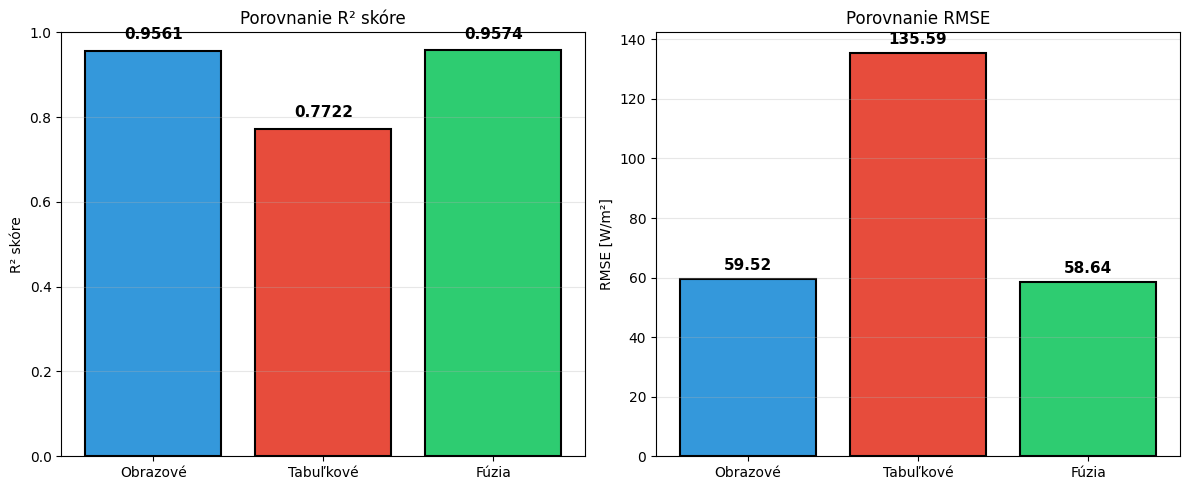

Graf uložený: c:\Users\pmuzslay\suns_z3\figures\bonus_fusion_metrics.png


In [31]:
# Bar chart porovnania R² a RMSE
if len(tabular_available) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    model_names = ['Obrazové', 'Tabuľkové', 'Fúzia']
    r2_values = [result_image['r2'], result_tabular['r2'], result_fusion['r2']]
    rmse_values = [result_image['rmse'], result_tabular['rmse'], result_fusion['rmse']]
    colors = ['#3498db', '#e74c3c', '#2ecc71']

    # R² porovnanie
    ax1 = axes[0]
    bars1 = ax1.bar(model_names, r2_values, color=colors, edgecolor='black', linewidth=1.5)
    ax1.set_ylabel('R² skóre')
    ax1.set_title('Porovnanie R² skóre')
    ax1.set_ylim(0, 1)
    for bar, val in zip(bars1, r2_values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.4f}', 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')

    # RMSE porovnanie
    ax2 = axes[1]
    bars2 = ax2.bar(model_names, rmse_values, color=colors, edgecolor='black', linewidth=1.5)
    ax2.set_ylabel('RMSE [W/m²]')
    ax2.set_title('Porovnanie RMSE')
    for bar, val in zip(bars2, rmse_values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{val:.2f}', 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(fig_dir / 'bonus_fusion_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Graf uložený: {fig_dir / 'bonus_fusion_metrics.png'}")
else:
    print("Bonus sekcia sa preskakuje - žiadne tabuľkové príznaky")

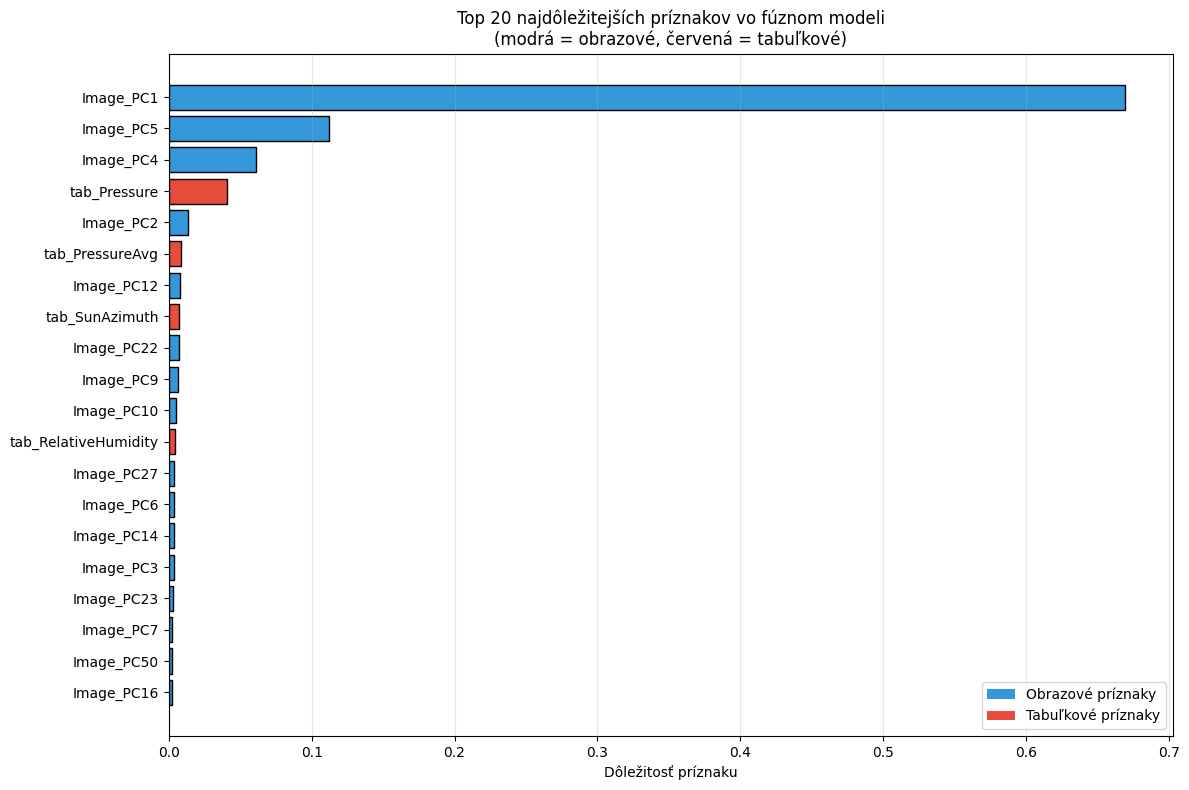


Súhrnná dôležitosť príznakov:
  Obrazové príznaky: 93.75%
  Tabuľkové príznaky: 6.25%


In [32]:
# Analýza dôležitosti príznakov vo fúznom modeli
if len(tabular_available) > 0:
    # Vytvoríme názvy príznakov
    image_feature_cols = [f'Image_PC{i+1}' for i in range(X_img_train.shape[1])]
    tabular_feature_cols = [f'tab_{c}' for c in tabular_available]
    feature_names = image_feature_cols + tabular_feature_cols
    
    feature_importance = result_fusion['model'].feature_importances_

    # Zoradíme podľa dôležitosti
    sorted_idx = np.argsort(feature_importance)[::-1][:20]  # Top 20

    fig, ax = plt.subplots(figsize=(12, 8))
    top_features = [feature_names[i] for i in sorted_idx]
    top_importance = feature_importance[sorted_idx]

    # Farba podľa typu príznaku
    bar_colors = ['#3498db' if 'Image' in f else '#e74c3c' for f in top_features]

    bars = ax.barh(range(len(top_features)), top_importance, color=bar_colors, edgecolor='black')
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features)
    ax.invert_yaxis()
    ax.set_xlabel('Dôležitosť príznaku')
    ax.set_title('Top 20 najdôležitejších príznakov vo fúznom modeli\n(modrá = obrazové, červená = tabuľkové)')
    ax.grid(True, alpha=0.3, axis='x')

    # Legenda
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#3498db', label='Obrazové príznaky'),
                       Patch(facecolor='#e74c3c', label='Tabuľkové príznaky')]
    ax.legend(handles=legend_elements, loc='lower right')

    plt.tight_layout()
    plt.savefig(fig_dir / 'bonus_fusion_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Súhrn typov príznakov
    image_importance = sum(feature_importance[:len(image_feature_cols)])
    tabular_importance = sum(feature_importance[len(image_feature_cols):])
    print(f"\nSúhrnná dôležitosť príznakov:")
    print(f"  Obrazové príznaky: {image_importance:.2%}")
    print(f"  Tabuľkové príznaky: {tabular_importance:.2%}")
else:
    print("Bonus sekcia sa preskakuje - žiadne tabuľkové príznaky")

## Záver bonusovej úlohy - Fúzia modelov

**Zistenia:**
1. **Fúzny model** kombinujúci obrazové a tabuľkové príznaky by mal dosahovať lepšie výsledky než jednotlivé modely
2. Obrazové príznaky zachytávajú vizuálnu informáciu o oblačnosti a slnečných podmienkach
3. Tabuľkové príznaky poskytujú presné numerické údaje o teplote, vlhkosti, tlaku a pozícii slnka
4. Kombinácia oboch typov príznakov umožňuje modelu využiť komplementárne informácie